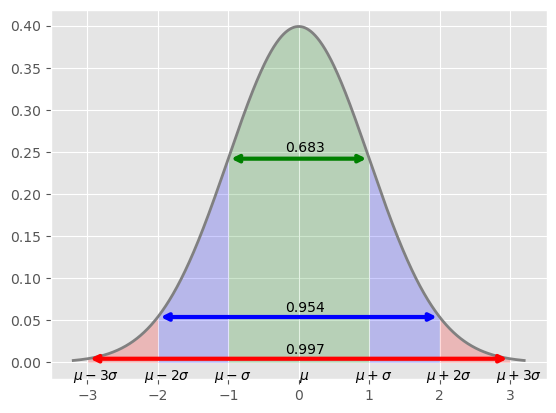

In [16]:
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt

import scipy.stats
from scipy import stats
plt.style.use('ggplot')

x = np.linspace(-3.2, 3.2, 1000)

#print(x)

iq = stats.norm(0,1) #평균 0, 분산 1 인 pdf

plt.plot(x, iq.pdf(x), 'gray', lw=2)

#글자 추가
plt.text(-3.2, -0.02, "$\mu - 3\sigma$")
plt.text(-2.2, -0.02, "$\mu - 2\sigma$")
plt.text(-1.2, -0.02, "$\mu - \sigma$")
plt.text(0, -0.02, "$\mu$")
plt.text(0.8, -0.02, "$\mu + \sigma$")
plt.text(1.8, -0.02, "$\mu + 2\sigma$")
plt.text(2.8, -0.02, "$\mu + 3\sigma$")

#표준편차에 따른 확률값 계산
std_1 = round(scipy.stats.norm(0,1).cdf(1) - scipy.stats.norm(0,1).cdf(-1), 3)  # Prb(X<1) - Prb(X<-1)
std_2 = round(scipy.stats.norm(0,1).cdf(2) - scipy.stats.norm(0,1).cdf(-2), 3)  # Prb(X<2) - Prb(X<-2)
std_3 = round(scipy.stats.norm(0,1).cdf(3) - scipy.stats.norm(0,1).cdf(-3), 3)  # Prb(X<3) - Prb(X<-3)

plt.text(-0.2, 0.25, std_1)
plt.text(-0.2, 0.06, std_2)
plt.text(-0.2, 0.01, std_3)

#화살표 추가
plt.annotate("", xy=(-1, scipy.stats.norm(0,1).pdf(-1))
               , xytext=(1, scipy.stats.norm(0,1).pdf(1)) 
               , arrowprops=dict(arrowstyle="<->", connectionstyle="arc3", color='green', lw=3))

plt.annotate("", xy=(-2, scipy.stats.norm(0,1).pdf(-2))
               , xytext=(2, scipy.stats.norm(0,1).pdf(2)) 
               , arrowprops=dict(arrowstyle="<->", connectionstyle="arc3", color='blue', lw=3))

plt.annotate("", xy=(-3, scipy.stats.norm(0,1).pdf(-3))
               , xytext=(3, scipy.stats.norm(0,1).pdf(3)) 
               , arrowprops=dict(arrowstyle="<->", connectionstyle="arc3", color='red', lw=3))

#그래프 색지정
colors = ['red', 'blue', 'green']
colors = colors + list(reversed(colors))

mean, std = 0, 1
for i, color in zip(range(-3, 3), colors):
    # -3 붉은색, -2 파란색, -1 초록색, 0 초록색, 1 파란색, 2 붉은색
    low = mean + i * std
    high = mean + (i + 1) * std
    px = x[np.logical_and(x >= low, x <= high)]
    plt.fill_between(px, iq.pdf(px), color=color, alpha=0.2, linewidth=0)
    